Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
156 153
Given the Array: 
<built-in method flatten of numpy.ndarray object at 0x7efbed1dbe10>
Predict this y: 
 [[0.24759615]]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

...

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0742
Epoch 2/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0208
Epoch 3/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0180
Epoch 4/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0161
Epoch 5/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0085
Epoch 6/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0077
Epoch 7/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0041
Epoch 8/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0053
Epoch 9/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0047
Epoch 10/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048
Epoch 11/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0038
Epoch 12/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0032
Epoch 13/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0034
Epoch 14/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0043
Epoch 15/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0

/tmp/ipykernel_824/458474977.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


23.097237020402655


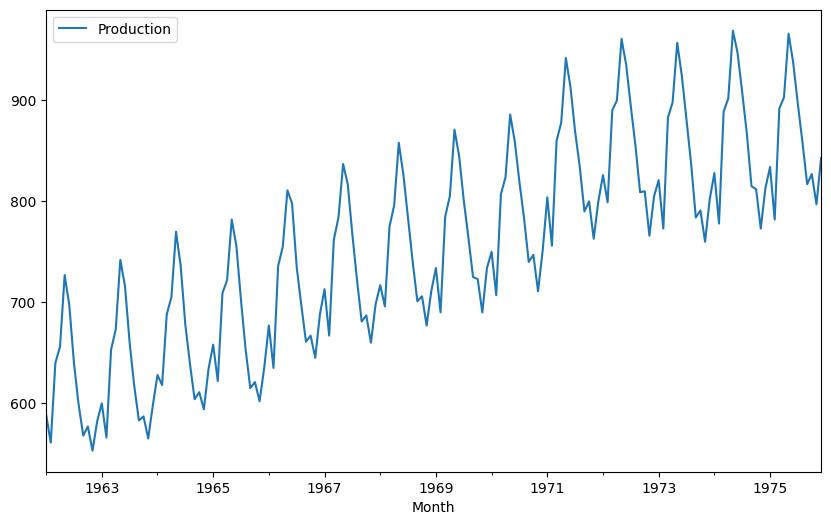

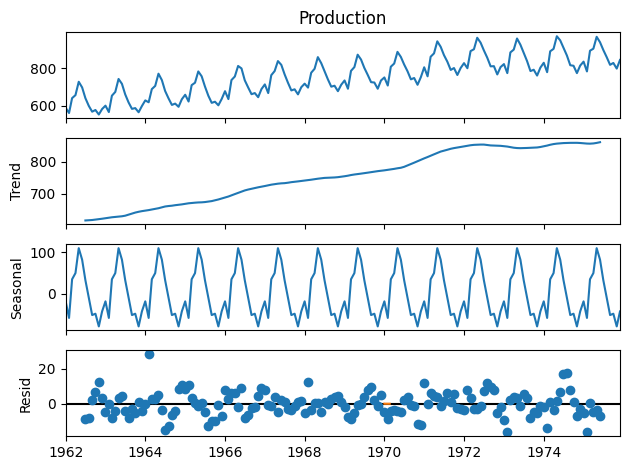

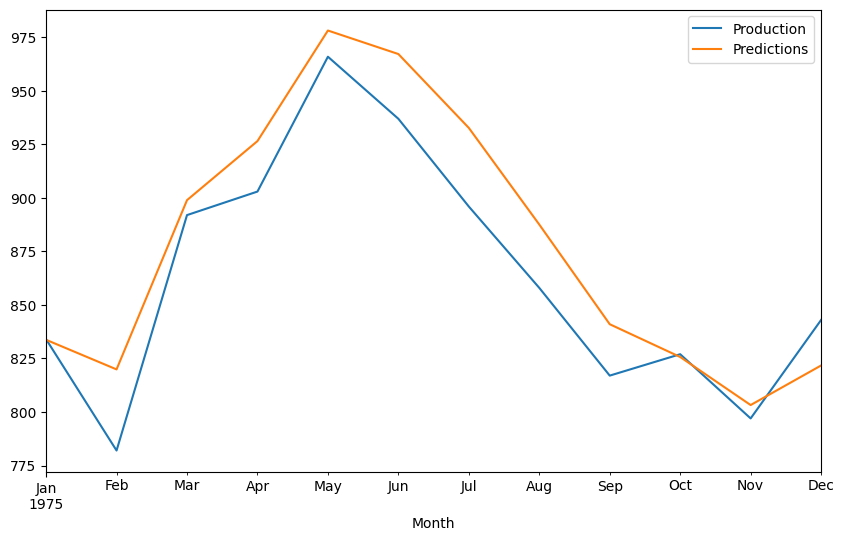

In [ ]:
# -*- coding: utf-8 -*-
"""LSTM.ipynb
Automatically generated by Colaboratory.
Original file is located at
https://colab.research.com/drive/19SKdhO8GsH-bNjjdExu1AFMfA5MjNZ93
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Updated path for the CSV file.
# Read without a header, assuming the first line is descriptive. The problematic string also appears as a footer.
df = pd.read_csv('/content/monthly-milk-production-pounds.csv', header=None, engine='python')

# Drop the first row (descriptive header) and the last row (problematic footer string)
df = df.iloc[1:-1]

# Correcting column names and setting index
df.columns = ['Month', 'Production']
df['Month'] = pd.to_datetime(df['Month'])
df['Production'] = pd.to_numeric(df['Production']) # Convert Production to numeric
df = df.set_index('Month')

df.index.freq='MS'
df.head()
df.plot(figsize=(10,6))
from statsmodels.tsa.seasonal import seasonal_decompose
results = seasonal_decompose(df['Production'])
results.plot()
len(df)
train = df.iloc[:156]
test = df.iloc[156:]
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df.head(),df.tail()
scaler.fit(train)
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)
scaled_train[:10]
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
n_input = 3
n_features = 1

generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
print(len(scaled_train),len(generator))
from numpy.random.mtrand import f
x,y = generator[0]
print(f'Given the Array: \n{x.flatten}')
print(f'Predict this y: \n {y}')
x.shape
n_input = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, length=n_input, batch_size=1)
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
model =Sequential()
model.add(LSTM(100, activation='relu', input_shape=(n_input, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()
model.fit(generator, epochs=50)
loss_per_epoch = model.history.history['loss']
plt.plot(range(len(loss_per_epoch)),loss_per_epoch)
last_train_batch = scaled_train[-12:]
last_train_batch = last_train_batch.reshape(1, n_input, n_features)
model.predict(last_train_batch)
scaled_test[0]
test_predictions = []
first_eval_batch = scaled_train[-n_input:]
current_batch = first_eval_batch.reshape((1, n_input, n_features))
for i in range(len(test)):
    current_pred = model.predict(current_batch)[0]
    test_predictions.append(current_pred)
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)
test_predictions
test.head()
true_predictions = scaler.inverse_transform(test_predictions)
test['Predictions'] = true_predictions

test.plot(figsize=(10,6))
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse = sqrt(mean_squared_error(test['Production'],test['Predictions']))
print(rmse)